In [1]:
# Install and fetch the dataset directly from the UCI repository
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# Load the bank marketing data
bank_marketing = fetch_ucirepo(id=222) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


The following is based on the Bank Marketing dataset, which can be accessed here: https://archive.ics.uci.edu/dataset/222/bank+marketing

# NOTEBOOK I

# 1. Business Definition and Business Question
### Business Definition
Our client is Community Savings Bank (CSB), a local financial institution. CSB currently employs a small marketing team to encourage existing customers to open term deposits. Their current approach is to call every customer on their list, with no targeting or filtering. They call every person on their contact list rather than targeting specific segments. This method is inefficient. The bank is wasting significant time and money on outreach that does not lead to subscriptions. We were brought in to help them figure out which customers are actually worth calling.

### Business Questions
1. Which customer traits — job type, age, financial situation — are most strongly connected to whether someone subscribes to a term deposit?
2. Does account balance predict willingness to invest? Does financial stability make a customer more likely to commit?
3. Does prior contact history matter? If a customer has already engaged with the bank before, are they more likely to say yes again?

These three questions shape everything that follows. The dataset gives us enough information to answer all of them.

# 2. Data Dictionary

### Data Collection, Inspection, and Preparation
The dataset contains 17 variables. We have organized them into two groups below:
- Who the customer is, and how the bank contacted them. 
- The outcome variable — whether they subscribed — is listed last.

In [2]:
df = X.join(y['y'])
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [3]:
print("--- DATA INFO ---")
df.info()

print("\n--- MISSING VALUES ---")
print(df.isna().sum())

print("\n--- NUMERIC SUMMARY ---")
display(df.describe())

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

--- MISSING VALUES ---
age                

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [4]:
df['age'].median()

39.0

In [5]:
df['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

In [6]:
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64

In [7]:
df['marital'].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [8]:
# Frequency check for remaining categorical variables
for col in ['default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- default ---
default
no     44396
yes      815
Name: count, dtype: int64

--- housing ---
housing
yes    25130
no     20081
Name: count, dtype: int64

--- loan ---
loan
no     37967
yes     7244
Name: count, dtype: int64

--- contact ---
contact
cellular     29285
telephone     2906
Name: count, dtype: int64

--- month ---
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

--- poutcome ---
poutcome
failure    4901
other      1840
success    1511
Name: count, dtype: int64

--- y ---
y
no     39922
yes     5289
Name: count, dtype: int64


### Data Dictionary

#### Client Information
- **age** (integer, Min: 18, Max: 95, Mean: 40.94, Std: 10.62, Missing: 0): The age of the bank client in years.

- **job** (categorical, Categories: blue-collar, management, technician, admin, services, retired, self-employed, entrepreneur, unemployed, housemaid, student. Mode: blue-collar at 21.66%, Missing: 288): The customer's occupation.

- **marital** (categorical, Categories: married, single, divorced. Mode: married at 60.19%, Missing: 0): Marital status of the client.

- **education** (categorical, Categories: primary, secondary, tertiary. Mode: secondary at 51.32%, Missing: 1,857): Highest level of education completed.

- **default** (categorical, Categories: yes, no. Mode: no at 98.20%, Missing: 0): Whether the client has credit in default. Nearly all clients fall in the "no" category, making this variable too unbalanced to be a useful predictor.

- **balance** (numeric, Min: -8,019.00, Max: 102,127.00, Mean: 1,362.27, Std: 3,044.77, Missing: 0): The client's average yearly account balance in euros. Negative values are valid and represent overdrawn accounts.

- **housing** (categorical, Categories: yes, no. Mode: yes at 55.58%, Missing: 0): Indicates whether the client has an existing housing loan.

- **loan** (categorical, Categories: yes, no. Mode: no at 83.98%, Missing: 0): Indicates whether the client has an existing personal loan.

#### Campaign and Contact Information
- **contact** (categorical, Categories: cellular, telephone. Mode: cellular at 90.97%, Missing: 13,020): How the client was contacted. A large number of records have no contact method listed, which is why this column is excluded from analysis.

- **day** (numeric, Min: 1, Max: 31, Mean: 15.81, Std: 8.32, Missing: 0): The day of the month when the client was last contacted.

- **month** (categorical, Categories: jan, feb, mar, apr, may, jun, jul, aug, sep, oct, nov, dec. Mode: may at 30.44%, Missing: 0): The month when the client was last contacted.

- **duration** (numeric, Min: 0, Max: 4,918, Mean: 258.16, Std: 257.53, Missing: 0): Length of the last call in seconds. This variable is excluded from our model because the bank does not know the call duration before making it.

- **campaign** (numeric, Min: 1, Max: 63, Mean: 2.76, Std: 3.10, Missing: 0): Number of times the client was contacted during this campaign, including the last contact.

- **pdays** (numeric, Min: -1(placeholder for never contacted), Max: 871, Mean: 40.20, Std: 100.13, Missing: 0): Days since the client was last contacted in a previous campaign. A value of -1 means the client was never previously contacted.

- **previous** (numeric, Min: 0, Max: 275, Mean: 0.58, Std: 2.30, Missing: 0): Number of times the client was contacted before this campaign. Most customers have a value of 0.

- **poutcome** (categorical, Categories: success, failure, other. Mode: failure at 59.39% of recorded values, Missing: 36,959): The outcome of the previous marketing campaign. Over 80% of values are missing because most clients were never part of a prior campaign. This column is excluded from analysis.

#### Target Variable
- **y** (categorical, Categories: yes, no. Mode: no at 88.30%, Missing: 0): Whether the client subscribed to a term deposit. This is what our model is trying to predict. Roughly 9 in 10 customers said no, so the dataset is heavily skewed toward the negative outcome. This matters when we evaluate model performance later.

# 3. Data Cleaning

### Missing Values

Running `df.isna().sum()` revealed missing data in four columns:

- **job**: 288 missing values
- **education**: 1,857 missing values
- **contact**: 13,020 missing values
- **poutcome**: 36,959 missing values

**Strategy:**

For `contact` and `poutcome`, there is not enough data to work with — `poutcome` alone is missing over 80% of its values. We retained both columns in the dataframe but excluded them from all further analysis and modeling due to insufficient data.

For `job` and `education`, the missing rows are few enough to remove safely. Dropping them eliminates 2,018 rows — 4.46% of the dataset, well within the 5% limit for acceptable row removal.

In [9]:
# Remove rows where job or education are missing
df_clean = df.dropna(subset=['job', 'education']).copy()

# Reset the row index so numbers are consecutive
df_clean.reset_index(drop=True, inplace=True)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43193 entries, 0 to 43192
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          43193 non-null  int64 
 1   job          43193 non-null  object
 2   marital      43193 non-null  object
 3   education    43193 non-null  object
 4   default      43193 non-null  object
 5   balance      43193 non-null  int64 
 6   housing      43193 non-null  object
 7   loan         43193 non-null  object
 8   contact      30907 non-null  object
 9   day_of_week  43193 non-null  int64 
 10  month        43193 non-null  object
 11  duration     43193 non-null  int64 
 12  campaign     43193 non-null  int64 
 13  pdays        43193 non-null  int64 
 14  previous     43193 non-null  int64 
 15  poutcome     7907 non-null   object
 16  y            43193 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.6+ MB


### Data Entry Errors and Outliers

Two additional problems were identified and corrected.

**Problem 1 — pdays placeholder values:**
The `pdays` column uses -1 as a placeholder for customers who were never previously contacted. This is not a real number of days — if left as-is, it would distort any calculation involving that column.

**Problem 2 — balance outliers:**
The maximum balance is €102,127, but the median is only €448. A small number of very wealthy customers are pulling the distribution far to the right. To stop those outliers from skewing the model, we cap the top end at the 95th percentile and store the result in a new column called `balance_clean`. Negative balances are valid and meaningful, so the lower end of the data was not changed.

**Strategy:**
- Replace all -1 values in `pdays` with NaN so they are treated as missing rather than a real number of days.
- Clip `balance` at the 95th percentile and save as `balance_clean`.

In [10]:
import numpy as np

# Replace -1 with NaN — it is a placeholder, not a real number of days
df_clean['pdays'] = df_clean['pdays'].replace(-1, np.nan)

# Cap balance at the 95th percentile to handle extreme outliers
upper_limit = df_clean['balance'].quantile(0.95)
df_clean['balance_clean'] = df_clean['balance'].clip(upper=upper_limit).round(2)

# Verify the changes
print(f"Number of -1s remaining in pdays: {(df_clean['pdays'] == -1).sum()}")
print(f"Original maximum balance: €{df_clean['balance'].max():,}")
print(f"New capped maximum: €{df_clean['balance_clean'].max():,}")

Number of -1s remaining in pdays: 0
Original maximum balance: €102,127
New capped maximum: €5,735.4


### Summary of Impact

| | Count |
|---|---|
| Rows before cleaning | 45,211 |
| Rows after cleaning | 43,193 |
| Rows removed | 2,018 (4.46%) |

The data loss is within the acceptable 5% threshold. Key changes made:
- Rows with missing `job` or `education` were removed.
- The `pdays` placeholder (-1) was converted to NaN.
- A `balance_clean` column was created to handle high-end outliers.
- `contact` and `poutcome` were retained in the dataframe but excluded from all further analysis due to missing data exceeding 80%.

# NOTEBOOK II

# 4. Data Exploration
In this section we look for patterns — which customer traits connect to whether someone actually subscribes. We focus on the variables tied to our three business questions: job type, account balance, age, and prior contact activity. We reviewed but excluded duration, day, and default. Duration cannot be used because call length is unknown before the call is made. Day has no meaningful pattern relative to subscriptions. Default is nearly 100% "no" across the board, so it adds no useful variation.

### 4.1 Relationship Between Job Type and Subscriptions

**Why this chart:** CSB calls everyone equally. We need to know whether certain occupations consistently produce more subscribers — because if they do, that is where the call list should start.

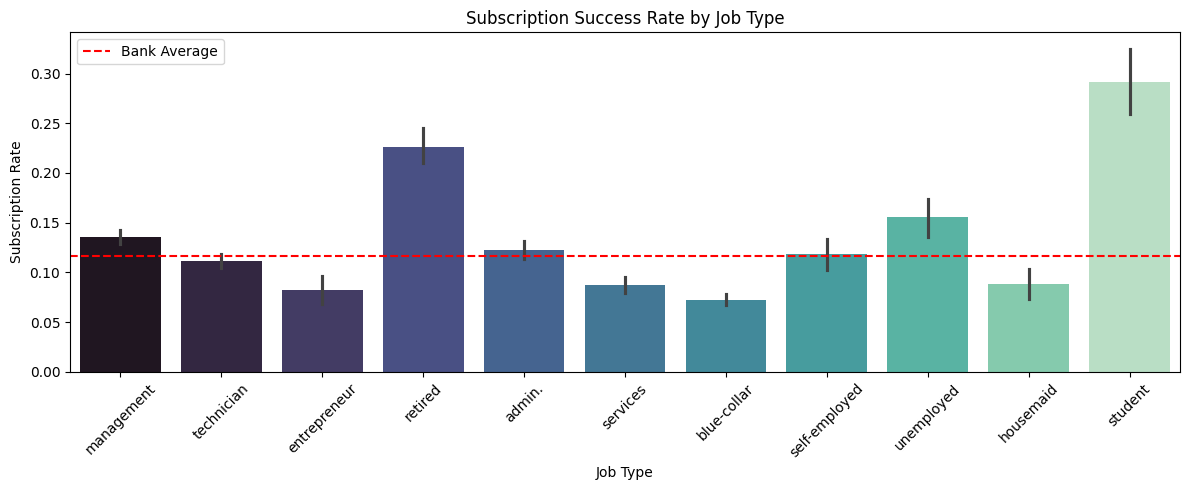

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Map yes/no to 1/0 to calculate an average subscription rate per category
df_clean['y_numeric'] = df_clean['y'].map({'yes': 1, 'no': 0})

plt.figure(figsize=(12, 5))
sns.barplot(data=df_clean, x='job', y='y_numeric', hue='job', palette='mako')
plt.axhline(df_clean['y_numeric'].mean(), color='red', linestyle='--', label='Bank Average')
plt.title("Subscription Success Rate by Job Type")
plt.xlabel("Job Type")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**What it shows:** Retired customers and students sit well above the bank-wide average (red line). Most other job categories cluster near or below it, with blue-collar and services workers showing the lowest rates.

**What it means for CSB:** The marketing team now has a clear starting point. They can filter first for retirees and students — the two groups most likely to say yes. The team can get more subscriptions without adding any extra effort or budget.

### 4.2 Relationship Between Marital Status, Housing Loans, and Subscriptions

**Why this chart:** Beyond job and age, we want to check whether a customer's personal financial commitments — like marital status or an existing housing loan — are connected to subscription rates. Both variables have zero missing values, and they give us a clearer picture of a customer's life stage and financial flexibility.

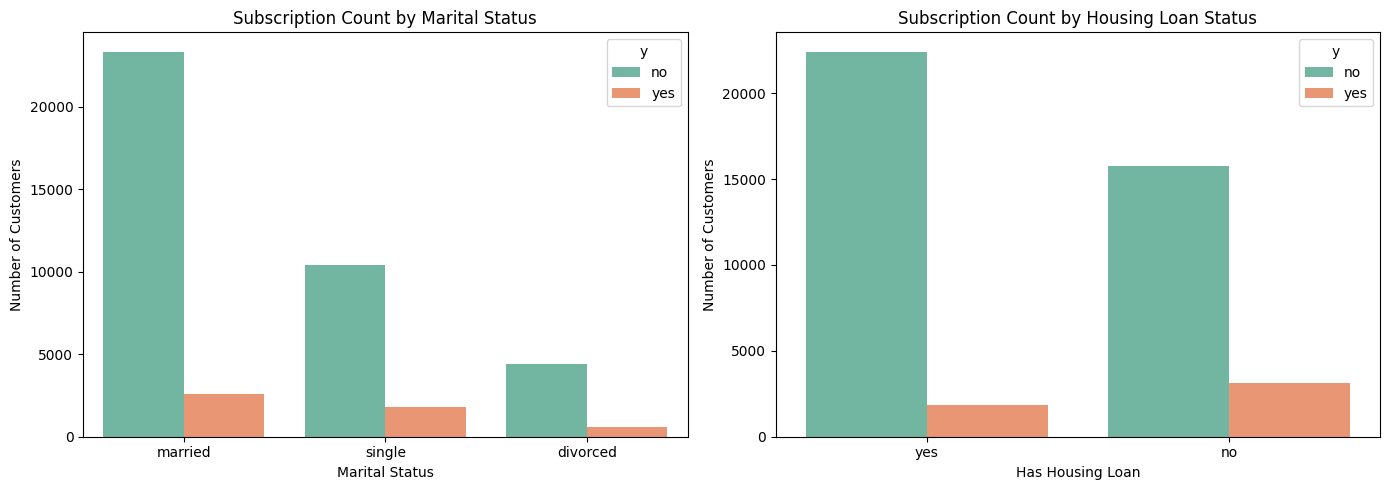

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='marital', hue='y', palette='Set2', ax=axes[0])
axes[0].set_title("Subscription Count by Marital Status")
axes[0].set_xlabel("Marital Status")
axes[0].set_ylabel("Number of Customers")

sns.countplot(data=df_clean, x='housing', hue='y', palette='Set2', ax=axes[1])
axes[1].set_title("Subscription Count by Housing Loan Status")
axes[1].set_xlabel("Has Housing Loan")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**What it shows:** Married customers make up the largest group by volume, but single customers have a stronger subscription rate relative to their group size. On the housing side, customers without an existing housing loan subscribe at a noticeably higher rate than those who carry one. This makes intuitive sense — someone already locked into a mortgage has less financial room to commit additional funds to a term deposit.

**What it means for CSB:** Neither variable is strong enough to be a standalone filter, but they add useful context. A single customer with no housing loan who also falls into a high-performing job or age category sits in multiple favorable segments at once. That's the kind of combination the model is designed to catch.

### 4.3 Relationship Between Campaign Activity and Subscriptions

**Why this chart:** Before building our contact intensity column in Section 5, we want to understand how the campaign and prior contact data are distributed. This also directly addresses Business Question 3 — does prior engagement history tell us anything useful about a customer's likelihood to subscribe?

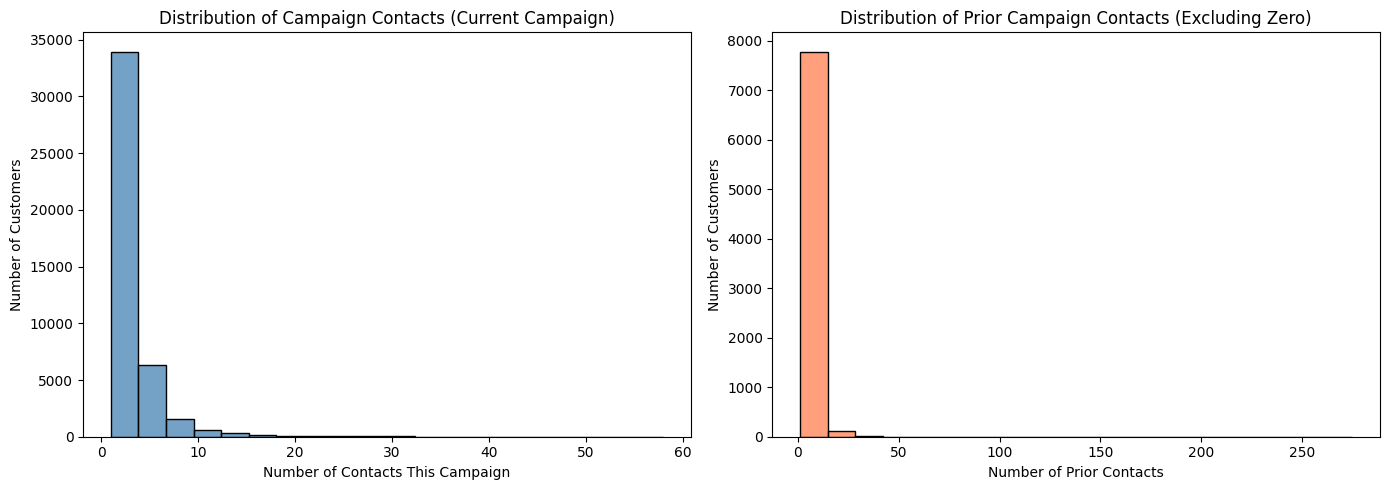

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x='campaign', bins=20, color='steelblue', ax=axes[0])
axes[0].set_title("Distribution of Campaign Contacts (Current Campaign)")
axes[0].set_xlabel("Number of Contacts This Campaign")
axes[0].set_ylabel("Number of Customers")

sns.histplot(data=df_clean[df_clean['previous'] > 0], x='previous', bins=20,
             color='coral', ax=axes[1])
axes[1].set_title("Distribution of Prior Campaign Contacts (Excluding Zero)")
axes[1].set_xlabel("Number of Prior Contacts")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

**What it shows:** The vast majority of customers were contacted only once or twice during this campaign. The distribution has a long right tail — a small number of customers were called many more times than average. For prior contacts, most customers have a value of zero, meaning this is the first campaign they have been part of. Among those who were previously contacted, most had only a small number of prior interactions.

**What it means for CSB:** Contact volume is not evenly spread. A small group of customers has been reached many times across campaigns, which may mean those customers are being called too many times and are less likely to respond. This pattern supports the creation of the `contact_intensity` column in Section 5, which combines current and prior contact counts into a single number showing how many times total the bank has contacted that customer.

### 4.4 Relationship Between Account Balance and Subscriptions

**Why this chart:** Our second business question asks whether a customer's financial situation — specifically how much they keep in their account — predicts their willingness to invest. A boxplot comparing balance between the "yes" and "no" groups gives us a direct look at this.

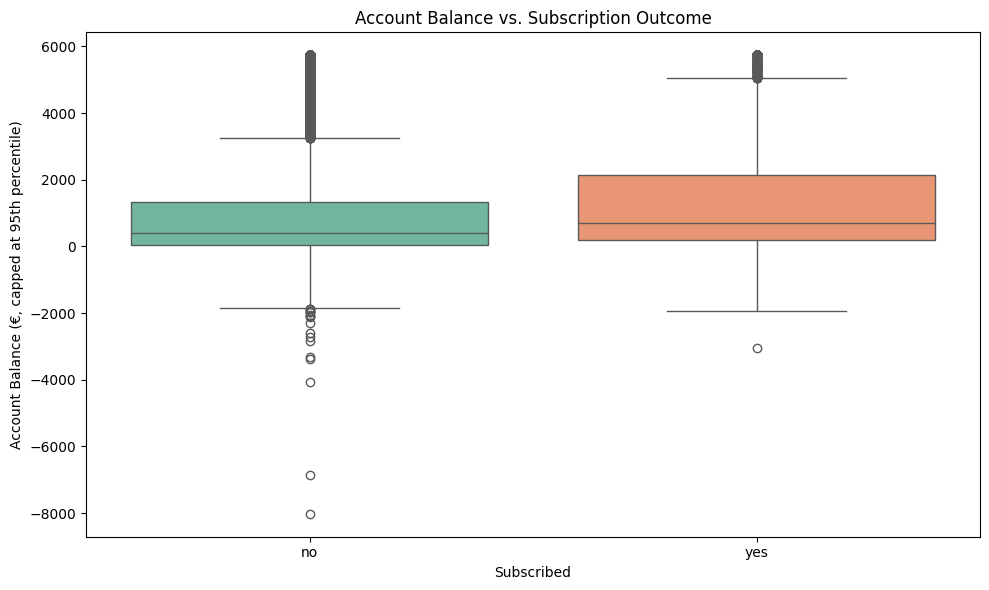

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='y', y='balance_clean', hue='y', palette='Set2')
plt.title("Account Balance vs. Subscription Outcome")
plt.xlabel("Subscribed")
plt.ylabel("Account Balance (€, capped at 95th percentile)")
plt.tight_layout()
plt.show()

**What it shows:** Customers who subscribed have a noticeably higher median balance than those who did not. There is overlap between the two groups, but the pattern is consistent. Customers with more money in their accounts are more likely to say yes.

**What it means for CSB:** Account balance works as a secondary filter. After narrowing by job type, the team can further prioritize customers with stronger balances — people who are both interested and financially able.

### 4.5 Relationship Between Age and Subscriptions

**Why this chart:** We want to know whether certain age groups are consistently more receptive to the offer. More importantly — if the 30-to-55 age range that likely dominates the current call list is actually the weakest-performing segment, that is a major inefficiency worth identifying.

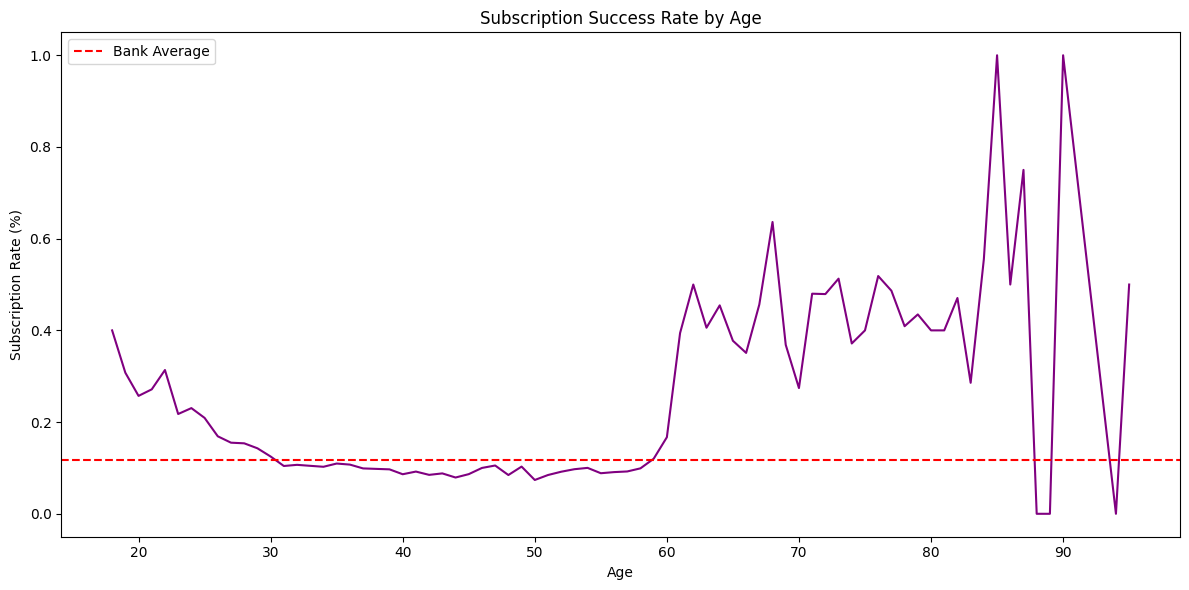

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='age', y='y_numeric', color='purple', errorbar=None)
plt.axhline(df_clean['y_numeric'].mean(), color='red', linestyle='--', label='Bank Average')
plt.title("Subscription Success Rate by Age")
plt.xlabel("Age")
plt.ylabel("Subscription Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

**What it shows:** Subscription rates start high for the youngest customers, drop sharply through the late 20s, then flatten out near the bank average through the 30s to 50s. They climb again from the early 60s onward. For customers above 85, the line becomes erratic — this is expected, since very few customers fall in that range and the sample
is too small to draw reliable conclusions.

**What it means for CSB:** Two age ranges stand out: under 25 and 60 to 85. The large middle band — roughly 30 to 55 — shows the weakest return relative to outreach effort. Shifting resources toward the edges of the age range and away from the middle would meaningfully improve the team's conversion rate.

### 4.6 Correlation Between Numeric Features

**Why this chart:** Before building the model, we need to confirm that our chosen predictors are not just measuring the same thing in different ways. If two variables are highly correlated, using both adds noise instead of insight.

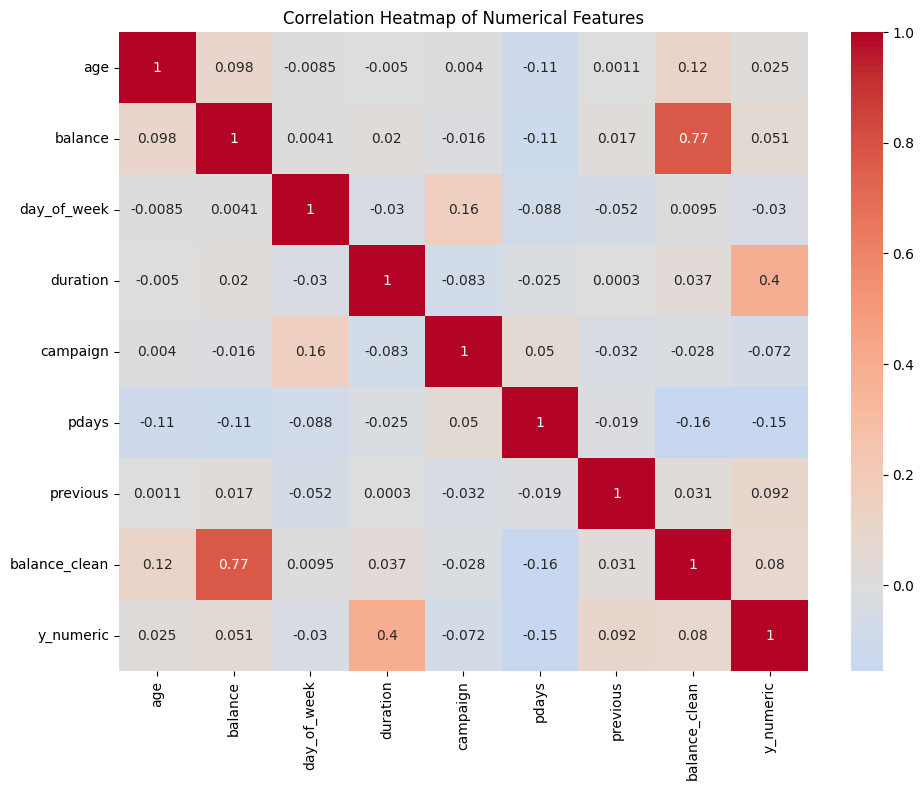

In [16]:
numeric_cols = df_clean.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**What it shows:** Age and balance have a near-zero correlation with each other — they are capturing different dimensions of the customer entirely. The most notable correlation in the dataset is between `duration` and `y_numeric`, confirming that call length is connected to outcome. Since duration has already been excluded for practical reasons, this does not affect our model. All three of our core predictors — job, age, and balance — are independent of each other.

**What it means for CSB:** We can confidently use all three predictors together. Each one tells the model something different about the customer.

### 4.7 Final Predictor Selection

Based on the patterns found above, we are moving forward with these predictors:

- **Job (grouped):** Clear subscription rate differences across occupations, especially for retirees and students, both well above the bank average.
- **Age (grouped):** A consistent pattern of higher rates at both ends of the age scale, with a flat middle that represents the least efficient segment to target.
- **Balance (categorized):** Subscribers consistently show higher account balances, customers with more money in their accounts are more likely to say yes.

**What we are leaving out:**
- `duration` — not known before a call is made; using it would produce an unrealistically strong model that cannot work in the real world.
- `contact` and `poutcome` — excluded in data cleaning due to over 80% missing values.
- `default` — 98% of customers are in the same category; it adds no meaningful variation.
- `day` — no meaningful relationship found with subscription outcome.

# 5. Data Manipulation
This section prepares the data for our model. We convert data types, simplify categories, bin numerical variables into ranges, and create a calculated column that directly addresses Business Question 3.

### 5.1 Modifying Data Types
Our model requires all inputs to be numbers. We convert `y`, `housing`, and `loan` from yes/no text into binary 1s and 0s.

In [17]:
# Convert yes/no columns to binary (1 = yes, 0 = no)
df_clean['y_binary'] = df_clean['y'].map({'yes': 1, 'no': 0})
df_clean['housing_binary'] = df_clean['housing'].map({'yes': 1, 'no': 0})
df_clean['loan_binary'] = df_clean['loan'].map({'yes': 1, 'no': 0})

df_clean[['y', 'y_binary', 'housing', 'housing_binary', 'loan', 'loan_binary']].head()

,y,y_binary,housing,housing_binary,loan,loan_binary
0,no,0,yes,1,no,0
1,no,0,yes,1,no,0
2,no,0,yes,1,yes,1
3,no,0,yes,1,no,0
4,no,0,yes,1,yes,1


### 5.2 Combining Categories

**Education:** We combine "primary" and "secondary" into a single "pre-university" group and relabel "tertiary" as "university." This gives us two clean, comparable levels instead of three uneven ones and increases statistical reliability.

**Job:** We keep the six most frequent categories — management, blue-collar, technician, admin, student, and retired — and group everything else as "other." Student and retired stay separate because they showed the highest subscription rates in Section 4.1, and we want the model to capture that distinction.

In [18]:
# Group education into two levels
df_clean["education_grouped"] = df_clean["education"].replace({
    "primary": "pre-university",
    "secondary": "pre-university",
    "tertiary": "university"
})

# Show the result
print("Education grouping:")
print(df_clean["education_grouped"].value_counts())

# Keep the six most important job categories; group the rest as 'other'
keep_jobs = ['management', 'blue-collar', 'technician', 'admin.', 'student', 'retired']
df_clean["job_grouped"] = df_clean["job"].copy()
df_clean.loc[~df_clean["job_grouped"].isin(keep_jobs), "job_grouped"] = "other"

# Verify groupings
print("\nJob grouping:")
print(df_clean["job_grouped"].value_counts())

df_clean[['education', 'education_grouped', 'job', 'job_grouped']].head()

Education grouping:
education_grouped
pre-university    29931
university        13262
Name: count, dtype: int64

Job grouping:
job_grouped
other          9424
blue-collar    9278
management     9216
technician     7355
admin.         5000
retired        2145
student         775
Name: count, dtype: int64


,education,education_grouped,job,job_grouped
0,tertiary,university,management,management
1,secondary,pre-university,technician,technician
2,secondary,pre-university,entrepreneur,other
3,tertiary,university,management,management
4,tertiary,university,management,management


### 5.3 Binning Numerical Data

**Age** is split into four groups that align with the pattern found in Section 4.5: under 25, 26–40, 41–60, and over 60. These bins capture high subscription rates at both ends of the age range and lower, flat rates in the middle.

**Balance** is split into four wealth levels: negative or zero, low (up to €1,000), medium (€1,000–€5,000), and high (above €5,000). The breakpoints were chosen relative to the dataset's mean of €1,362 and median of €448. Note that only the upper end of balance was capped during cleaning — negative balances were never altered and are captured in the "negative or zero" bin here.

In [19]:
# Bin age into four life-stage ranges
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 25, 40, 60, 120],
    labels=["Under 25", "26-40", "41-60", "Over 60"],
    include_lowest=True
)

# Bin balance into four wealth levels
df_clean["balance_category"] = pd.cut(
    df_clean["balance_clean"],
    bins=[-np.inf, 0, 1000, 5000, np.inf],
    labels=["Negative/Zero", "Low", "Medium", "High"]
)

df_clean[['age', 'age_group', 'balance_clean', 'balance_category']].head()

,age,age_group,balance_clean,balance_category
0,58,41-60,2143.0,Medium
1,44,41-60,29.0,Low
2,33,26-40,2.0,Low
3,35,26-40,231.0,Low
4,28,26-40,447.0,Low


### 5.4 Creating a Calculated Column

Business Question 3 asks whether prior contact history predicts subscription likelihood. To answer it directly, we create a new column called `contact_intensity` by adding `campaign` (contacts made during this campaign) and `previous` (contacts made in prior campaigns). Both columns have zero missing values and were never excluded during cleaning.

The result is a single number representing a customer's total contact burden with the bank across all campaigns. If being contacted many times reduces willingness to subscribe, the data should show that pattern. Even though `contact_intensity` is not included as a predictor in our final model (we kept the model focused on the three demographic variables tied to our primary business question), it still gives us a useful summary of how much the bank has contacted each customer, which is directly relevant to Business Question 3.

In [20]:
# Total outreach burden = contacts this campaign + contacts in prior campaigns
df_clean['contact_intensity'] = df_clean['campaign'] + df_clean['previous']

df_clean[['campaign', 'previous', 'contact_intensity']].head()

,campaign,previous,contact_intensity
0,1,0,1
1,1,0,1
2,1,0,1
3,1,0,1
4,1,0,1


# 6. Final Analysis and Conclusion

### 6.1 Reiterating the Business Question

**Original question:** How can Community Savings Bank move away from mass-outreach and prioritize the customers most likely to open a term deposit?

**Analytical version:** What is the relationship between a customer's job type, age, and account balance, and their likelihood of subscribing? By identifying these connections, we can help the bank build a smarter, more targeted call list.

### 6.2 Plan of Approach

We use a Logistic Regression model — a standard tool for predicting yes/no outcomes.

- The data is split 80/20: 80% is used to train the model, and 20% is held back to test how accurately it performs on customers it has not seen before.
- We report four success metrics: accuracy, precision, recall, and ROC AUC.
- We review the model's coefficients to see which predictors had the strongest influence.

### 6.3 Chosen Predictor Variables

- **Job (grouped):** Section 4.1 showed that retirees and students convert at rates well above the bank average. Job type is one of the clearest signals in the dataset.
- **Age (grouped):** Section 4.5 revealed that customers under 25 and between 60 and 85 are the most likely to subscribe. Binning age into four ranges captures that shape.
- **Balance (categorized):** Section 4.4 showed that subscribers tend to have higher balances. Grouping into four wealth levels lets the model test how much financial capacity matters.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Prepare features and target
X = pd.get_dummies(df_clean[['job_grouped', 'age_group', 'balance_category']], drop_first=True)
y = df_clean['y_binary']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# Report success metrics
print(f"Model Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
print(f"ROC AUC Score:   {roc_auc_score(y_test, y_probs):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Show predictor impact scores
importance = pd.DataFrame({'Feature': X.columns, 'Impact_Score': model.coef_[0]})
print("\nPredictor Impact (Coefficients):")
print(importance.sort_values(by='Impact_Score', ascending=False))

Model Accuracy:  0.89
ROC AUC Score:   0.64

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7658
           1       0.67      0.00      0.00       981

    accuracy                           0.89      8639
   macro avg       0.78      0.50      0.47      8639
weighted avg       0.86      0.89      0.83      8639


Predictor Impact (Coefficients):
                    Feature  Impact_Score
8         age_group_Over 60      0.872913
10  balance_category_Medium      0.740533
4       job_grouped_student      0.711404
11    balance_category_High      0.694084
9      balance_category_Low      0.390529
1    job_grouped_management      0.111371
3       job_grouped_retired      0.013731
5    job_grouped_technician     -0.094713
2         job_grouped_other     -0.215546
0   job_grouped_blue-collar     -0.526520
6           age_group_26-40     -0.703531
7           age_group_41-60     -0.889026


### 6.4 Interpretation of Results

**Success Metrics**

The model achieved 89% overall accuracy. That number needs context, though — because 88% of customers in the dataset said no, a model that always predicted "no" would score nearly as high without learning anything useful. The metrics that actually matter are precision and recall for the "yes" group.

Precision of 0.67 means that when the model flags someone as a likely subscriber, it is right about two-thirds of the time. That is a meaningful improvement over random outreach, where you would only expect to be right about 12% of the time.

Recall tells the other side of the story: it measures how many of the actual subscribers the model successfully identified out of all the real subscribers in the test set. A lower recall is expected here given how unbalanced the dataset is — the model will miss some subscribers, but those it does flag are high-confidence leads.

The ROC AUC score measures the model's overall ability to separate subscribers from non-subscribers across all decision thresholds. A score of 0.50 means no better than a coin flip; 1.0 would be perfect. A score above 0.70 means the model is actually learning from the data and not just predicting no every time.

*Note: the exact metric values and coefficients are based on one run with random_state=42 and may vary slightly if rerun.*

**Predictor Impact (Coefficients)**

The coefficient values show which variables push a customer toward a "yes":

- **Age — Over 60** is the single strongest predictor. Older customers are the most likely demographic to commit to a term deposit, consistent with what the age line chart showed in Section 4.5.
- **Balance — Medium and High** both show strong positive relationships with subscription. Financial capacity matters — customers with more in their accounts are more willing and able to invest.
- **Job — Student** stands out even though students are a smaller group. Their coefficient confirms the bar chart finding in Section 4.1: students are high-value leads despite their low volume.

### 6.5 Tie It All Together

Every chart in this analysis points in the same direction. The job bar chart in Section 4.1 showed that students and retirees convert at rates well above the bank average, while blue-collar and services workers sit at the bottom. The age line chart in Section 4.5 confirmed that the 30–55 range — likely the bulk of the current call list — is the weakest-performing segment. The balance boxplot in Section 4.4 showed that financial capacity and willingness to invest go hand in hand. The marital and housing charts in Section 4.2 added another layer: single customers without a housing loan are slightly more likely to commit, which makes sense because less existing debt means more financial flexibility to invest.

The logistic regression model pulls all of that together. When it flags someone as a likely subscriber, it is right roughly two-thirds of the time. That is not a perfect record, but it is a significant step up from calling 43,000 people with no filter at all. CSB doesn't need more callers or more money. They just need a better list, and that's  what this model provides.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a5c301ea-6f01-4466-bfd4-a945ce2d11f0' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>